In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [4]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [6]:
def sigmoid_derivative(output):
    return output*(1-output)

In [8]:
def forward_pass(X,W1,b1,W2,b2):
    hidden_input=np.dot(X,W1)+b1
    hidden_output=sigmoid(hidden_input)
    final_input=np.dot(hidden_output,W2)+b2
    final_output=sigmoid(final_input)
    return final_output,final_input,hidden_output,hidden_input

In [32]:
def plot_xor_decision_boundary(W1,b1,W2,b2):
    x_min,x_max=-0.5,1.5
    y_min,y_max=-0.5,1.5
    xx,yy=np.meshgrid(np.linspace(x_min,x_max,300),np.linspace(y_min,y_max,300))
    grid=np.c_[xx.ravel(),yy.ravel()]
    Z, _, _, _=forward_pass(grid,W1,b1,W2,b2)
    Z=Z.reshape(xx.shape)
    plt.figure(figsize=(8,6))
    plt.contourf(xx,yy,Z>0.5,alpha=0.6,cmap=ListedColormap(['red','blue']))
    plt.contour(xx,yy,Z,levels=[0.5],linewidths=1,colors='k')
    X_pts=np.array([[0,0],[0,1],[1,0],[1,1]])
    y_pts=np.array([0,1,1,0])
    for i in range(len(X_pts)):
        plt.scatter(X_pts[i][0],X_pts[i][1],c='black',s=100,edgecolors='white',linewidths=2)
        plt.text(X_pts[i][0]+0.03,X_pts[i][1]+0.03,f"{y_pts[i]}",fontsize=12,color='white',weight='bold')
    plt.title("XOR Decision Boundary")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.show()

In [34]:
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0], [1], [1], [0]])
print("Input for XOR Boolean Function:")
print(X)
print("Output for XOR Boolean Function:")
print(y)

Input for XOR Boolean Function:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output for XOR Boolean Function:
[[0]
 [1]
 [1]
 [0]]


In [36]:
np.random.seed(0)
input_size=2
hidden_size=2
output_size=1
lr=0.5
epochs=10000

In [38]:
W1=np.random.uniform(-1,1,(input_size,hidden_size))
b1=np.random.uniform(-1,1,(1,hidden_size))
W2=np.random.uniform(-1,1,(hidden_size,output_size))
b2=np.random.uniform(-1,1,(1,output_size))
errors=[]

In [40]:
for epoch in range(epochs):
    hidden_input=np.dot(X,W1)+b1
    hidden_output=sigmoid(hidden_input)
    final_input=np.dot(hidden_output,W2)+b2
    final_output=sigmoid(final_input)
    error=y-final_output
    mse=np.mean(np.square(error))
    errors.append(mse)
    delta_output=error*sigmoid_derivative(final_output)
    delta_hidden=delta_output.dot(W2.T)*sigmoid_derivative(hidden_output)
    W2+=hidden_output.T.dot(delta_output)*lr
    b2+=np.sum(delta_output,axis=0,keepdims=True)*lr
    W1+=X.T.dot(delta_hidden)*lr
    b1+=np.sum(delta_hidden,axis=0,keepdims=True)*lr

In [41]:
print("Final outputs after training:\n",final_output.round(4))

Final outputs after training:
 [[0.0197]
 [0.983 ]
 [0.983 ]
 [0.0176]]


In [42]:
print("\nXOR Truth Table with Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]} Target: {y[i][0]} → Predicted: {final_output[i][0]:.4f}")


XOR Truth Table with Predictions:
Input: [0 0] Target: 0 → Predicted: 0.0197
Input: [0 1] Target: 1 → Predicted: 0.9830
Input: [1 0] Target: 1 → Predicted: 0.9830
Input: [1 1] Target: 0 → Predicted: 0.0176


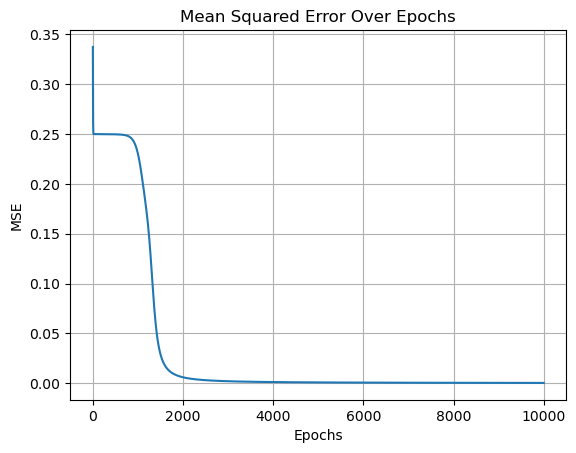

In [46]:
plt.plot(errors)
plt.title("Mean Squared Error Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

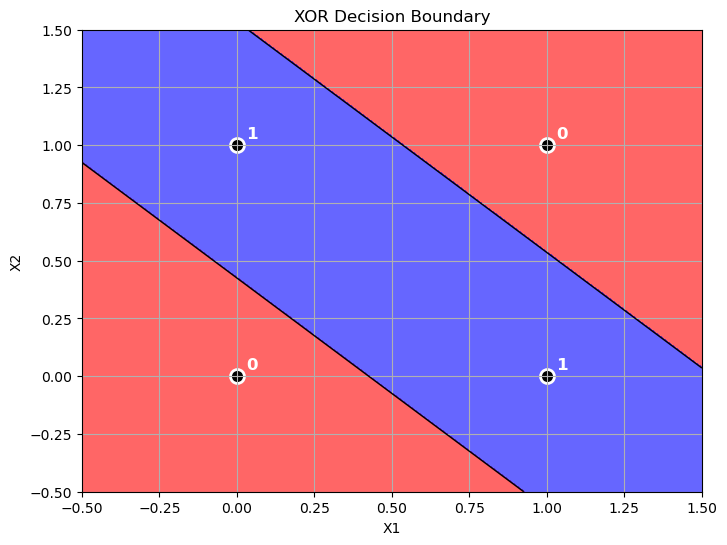

In [48]:
plot_xor_decision_boundary(W1,b1,W2,b2)